## IMPORT

In [2]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import KMeans
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression

## CODE

In [4]:
try:
    df = pd.read_csv("../../Supervise.csv") # Ouvre le csv
except FileNotFoundError:
    raise SystemExit(84)

matrices = np.load('../../Matrice.npy', allow_pickle=True) # Ouvre les matrices

X = matrices # Donne les matrices en données afin qu'il classe les IRM des patients en fonction de leurs maladies
y = df["target"] # Donne les différentes maladies possibles

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state=1
) # Split X et Y pour avoir une partie entraînement et une partie examen
clf = LogisticRegression()
clf = clf.fit(X_train, y_train) # Crée et entraîne le modèle

accuracy = clf.score(X_test, y_test) # Calcule la précision du bot ( le % d'IRM qu'il arrive à classer )

print("Accuracy :", accuracy) # Print la précision


y_pred = clf.predict(X_test)

print(confusion_matrix(y_test, y_pred)) # Crée la matrice de précision pour savoir avec plus de précision comment le bot arrive à classer les différentes maladies genre à combien de pourcent il devine que les patients atteints de stone sont atteints de stone.

raise SystemExit(0)


AttributeError: 'LogisticRegression' object has no attribute 'sccore'

/home/gabin/Documents/Project/B-SPE-311-LIL-3-1-cvrie-2/Myvenv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3831: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [18]:
try:
    df = pd.read_csv("../../Supervise.csv") # Ouvre le csv
except FileNotFoundError:
    raise SystemExit(84)

matrices = np.load('../../Matrice.npy', allow_pickle=True) # Ouvre les matrices

X = matrices # Donne les matrices en données afin qu'il classe les IRM des patients en fonction de leurs maladies
y = df["target"] # Donne les différentes maladies possibles
groupes = df['groupe']


gss = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=1)
train_idx, test_idx = next(gss.split(X, y, groups=groupes))
    
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


clf = LogisticRegression()
clf = clf.fit(X_train, y_train) # Crée et entraîne le modèle

accuracy = clf.score(X_test, y_test) # Calcule la précision du bot ( le % d'IRM qu'il arrive à classer )

print("Accuracy :", accuracy) # Print la précision


y_pred = clf.predict(X_test)



print(confusion_matrix(y_test, y_pred)) # Crée la matrice de précision pour savoir avec plus de précision comment le bot arrive à classer les différentes maladies genre à combien de pourcent il devine que les patients atteints de stone sont atteints de stone.

raise SystemExit(0)


Accuracy : 0.9251585623678646
[[816   2   0   0]
 [ 25 886 132   0]
 [  0  18 207   0]
 [  0   0   0 279]]


SystemExit: 0

/home/gabin/Documents/Project/B-SPE-311-LIL-3-1-cvrie-2/Myvenv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3831: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


#### On va ajouter des metrics supplémentaires pour analyser plus en profondeur notre modèle

In [19]:
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

print("\nRapport de classification détaillé :")
print(classification_report(y_test, y_pred))

Matrice de confusion :
[[816   2   0   0]
 [ 25 886 132   0]
 [  0  18 207   0]
 [  0   0   0 279]]

Rapport de classification détaillé :
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       818
           1       0.98      0.85      0.91      1043
           2       0.61      0.92      0.73       225
           3       1.00      1.00      1.00       279

    accuracy                           0.93      2365
   macro avg       0.89      0.94      0.91      2365
weighted avg       0.94      0.93      0.93      2365



##### Nous obtenons donc :
```
Matrice de confusion :
[[816   2   0   0]
 [ 25 886 132   0]
 [  0  18 207   0]
 [  0   0   0 279]]

Rapport de classification détaillé :
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       818
           1       0.98      0.85      0.91      1043
           2       0.61      0.92      0.73       225
           3       1.00      1.00      1.00       279

    accuracy                           0.93      2365
   macro avg       0.89      0.94      0.91      2365
weighted avg       0.94      0.93      0.93      2365
```

Cette analyse nous permet d'obtenir plusieurs indications clés.
Premièrement on remarque un déséquilibre on a 1043 images de la maladie 1 contre 300 ou 800 dans support.
Recall c'est sur le nombre d'images combien en % il arrive à parfaitement détecter, 0.85 étant le score le plus bas ce qui est acceptable.

Precision par contre c'est la sûreté de détection (savoir quand elle crie au loup) et elles sont toutes très performantes sauf pour la maladie 2, l'IA se trompe 4 fois sur 6.

La note globale qui est le f1 est tout de même assez bonne, seule la maladie 2 a des difficultés car elle ressemble trop mathématiquement à la maladie 1


On va essayer tout de même de rééquilibrer les proportions comme on a énormément de 1 et que le 2 est moins important.
Pour ce faire on va appliquer un poids équilibré avec `class_weight='balanced'` et lui mettre plus de `max_iter`.
Également on va faire une normalisation avec un MinMaxScaler.

Pourquoi notre modèle fonctionne sans MinMaxScaler ?
Il fonctionne grâce à des proportions partielles, LogisticRegression a besoin de données équilibrées, on ne peut pas lui donner un salaire entre 0 et 100000 et à côté donner l'âge entre 0 et 100 il ne va pas réussir. Mais comme nous utilisons des images nous restons entre 0 et 255 donc avec un certain équilibre. Mais nous allons quand même en effectuer une pour plus de rapidité et de précision.

In [4]:
try:
    df = pd.read_csv("../../Supervise.csv") # Ouvre le csv
except FileNotFoundError:
    raise SystemExit(84)

matrices = np.load('../../Matrice.npy', allow_pickle=True) # Ouvre les matrices

X = matrices # Donne les matrices en données afin qu'il classe les IRM des patients en fonction de leurs maladies
y = df["target"] # Donne les différentes maladies possibles
groupes = df['groupe']


gss = GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=1)
train_idx, test_idx = next(gss.split(X, y, groups=groupes))
    
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)   # fit SEULEMENT sur train
X_test = scaler.transform(X_test)

clf = LogisticRegression(class_weight='balanced', max_iter=1000)
clf = clf.fit(X_train, y_train) # Crée et entraîne le modèle

accuracy = clf.score(X_test, y_test) # Calcule la précision du bot ( le % d'IRM qu'il arrive à classer )

print("Accuracy :", accuracy) # Print la précision


y_pred = clf.predict(X_test)


print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

print("\nRapport de classification détaillé :")
print(classification_report(y_test, y_pred))


raise SystemExit(0)


Accuracy : 0.9221987315010571
Matrice de confusion :
[[816   2   0   0]
 [ 30 879 134   0]
 [  0  18 207   0]
 [  0   0   0 279]]

Rapport de classification détaillé :
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       818
           1       0.98      0.84      0.91      1043
           2       0.61      0.92      0.73       225
           3       1.00      1.00      1.00       279

    accuracy                           0.92      2365
   macro avg       0.89      0.94      0.90      2365
weighted avg       0.94      0.92      0.93      2365



SystemExit: 0

/home/gabin/Documents/Project/B-SPE-311-LIL-3-1-cvrie-2/Myvenv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3831: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


On obtient :

```
Accuracy : 0.9221987315010571
Matrice de confusion :
[[816   2   0   0]
 [ 30 879 134   0]
 [  0  18 207   0]
 [  0   0   0 279]]

Rapport de classification détaillé :
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       818
           1       0.98      0.84      0.91      1043
           2       0.61      0.92      0.73       225
           3       1.00      1.00      1.00       279

    accuracy                           0.92      2365
   macro avg       0.89      0.94      0.90      2365
weighted avg       0.94      0.92      0.93      2365
```

On voit donc une seule différence, la précision du 01 qui descend de 0.01.
Nos changements n'ont donc aucun effet, on ne peut pas pousser plus loin, nous avons atteint la limite du modèle de LogisticRegression, on ne peut simplement pas tracer une ligne parfaite entre la maladie 01 et 02.

##### Graphique pour visualiser notre résultat final

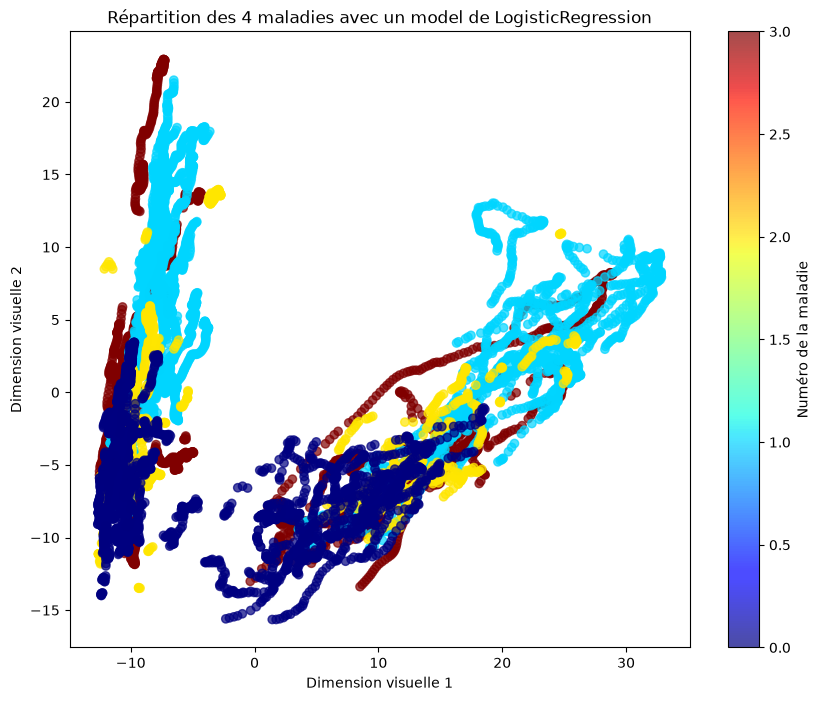

In [5]:
# on veut 2 coordonnées X et Y
pca = PCA(n_components=2)

#Transforme le vecteur de mes textes en vecteur 3D
points_2d = pca.fit_transform(X_train)

# on crée la figure
fig = plt.figure(figsize=(10, 8))
axe = fig.add_subplot(111)


nuage = axe.scatter(points_2d[:, 0], points_2d[:, 1], c=y_train, cmap='jet', alpha=0.7)


plt.title("Répartition des 4 maladies avec un model de LogisticRegression")
axe.set_xlabel("Dimension visuelle 1")
axe.set_ylabel("Dimension visuelle 2")


plt.colorbar(nuage, label="Numéro de la maladie")

plt.show()



#### Le résultat de notre graphique nous montre parfaitement nos résultats.
Le bleu ciel et le marron sont assez distincts côte à côte sans se chevaucher.
Mais le bleu foncé avec le jaune c'est une autre histoire, on voit que le bleu foncé prend le dessus sur le jaune. C'est le même résultat qu'avec notre f1-score, les deux étant trop proches l'un prend l'ascendant sur l'autre et on détecte mieux et plus souvent du bleu foncé que du jaune (maladie 2) qui est assez proche mathématiquement du bleu foncé (maladie 0)

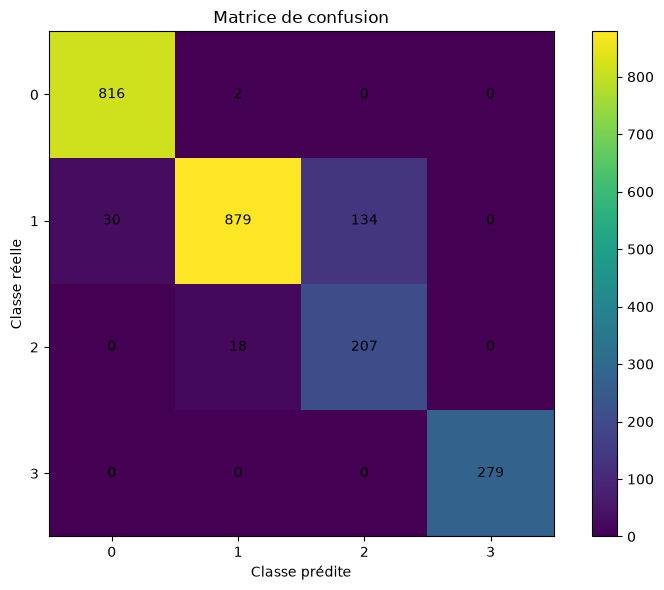

In [6]:
y_pred = clf.predict(X_test)
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Création du graphique
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm)

# Noms des classes
classes = clf.classes_

ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))

ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

# Ajouter les nombres dans les cases
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, cm[i, j],
                ha="center",
                va="center")

ax.set_xlabel("Classe prédite")
ax.set_ylabel("Classe réelle")
ax.set_title("Matrice de confusion")

plt.colorbar(im)
plt.tight_layout()
plt.show()